In [1]:
import os
import glob
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from nflows import flows, transforms, distributions
from nflows.transforms.normalization import ActNorm
from tqdm import tqdm

from src.diffeomorphisms.image.nflow import NFlowImageDiffeomorphism
from src.inverse_problems.plug_and_play_riemannian_ambient_flow import PnPRiemannianAmbientFlowProblem
from src.manifolds.euclidean.image.pullback.standard import StandardPullbackImageEuclidean
from src.manifolds.euclidean.image.standard import StandardImageEuclidean
from src.riemannian_autoencoder.image.pullback.l2_tangent_space_pca import l2TangentSpacePCAPullbackImageRiemannianAutoencoder
from src.riemannian_autoencoder.image.pullback.standard import StandardPullbackImageRiemannianAutoencoder
from src.transforms.multi_layer_parity_conv2d.tanh import MultiLayerTanhParityConv2DTransform
from src.transforms.parity_conv import ParityConv2DTransform

device = "cuda" if torch.cuda.is_available() else "cpu"

# Set random seed for reproducibility
torch.manual_seed(31)

# Experiment settings
folder_name = "mnist_inpainting_h28_w28_mask0.7_noise0.1_pgd_stepsize[0.99]_g[0.4]_sigma[0.99]_maxiter10"
data_folder_path = os.path.join("data","MNIST","reconstructed",f"{folder_name}")
results_folder_path = os.path.join("results","mnist","pnp_raf",f"{folder_name}")

In [2]:
# Plot original, noisy, and denoised images
def show_images(img_list, titles):
    fig, axes = plt.subplots(1, len(img_list), figsize=(12, 4))
    for i, (img, title) in enumerate(zip(img_list, titles)):
        axes[i].imshow(img[0].cpu().numpy().squeeze(), cmap="gray")
        axes[i].set_title(title)
        axes[i].axis("off")
    plt.tight_layout()
    plt.show()

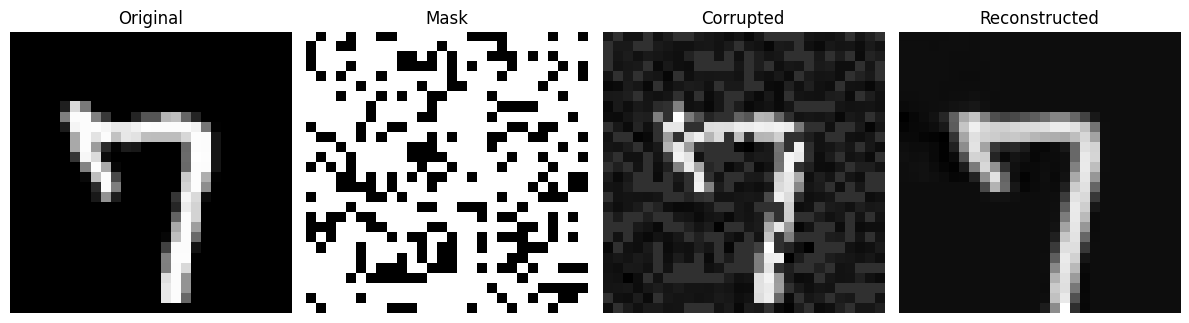

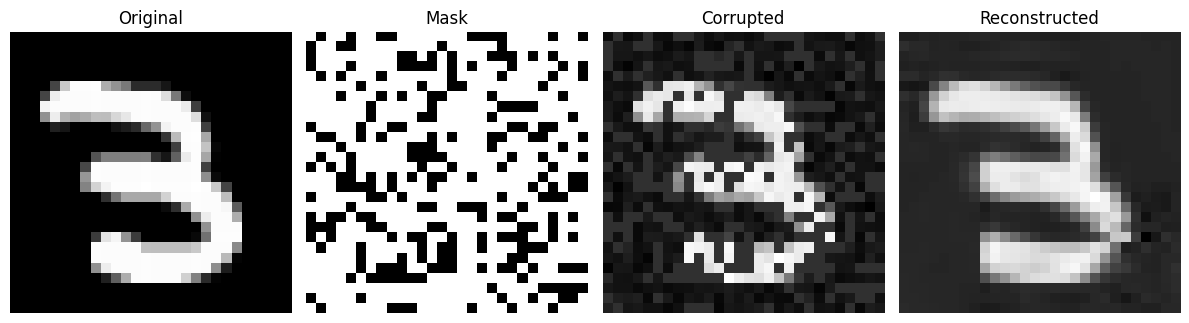

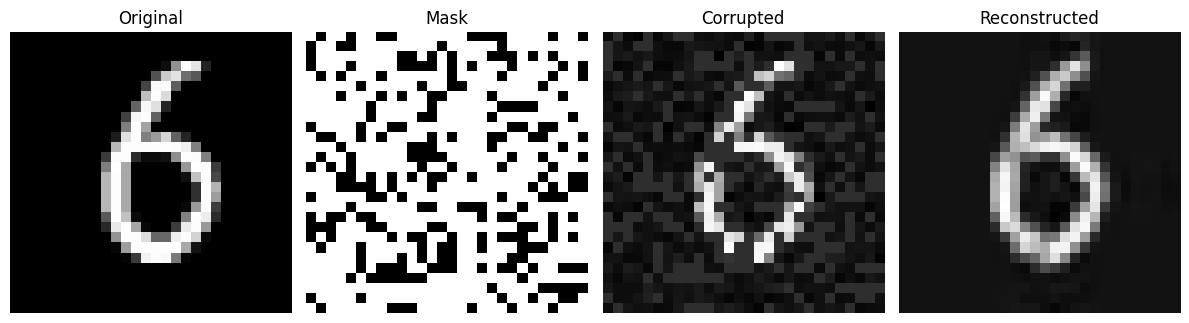

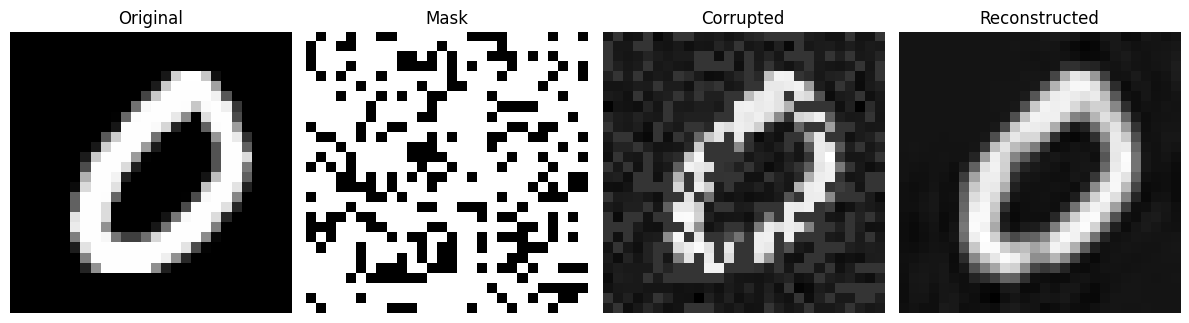

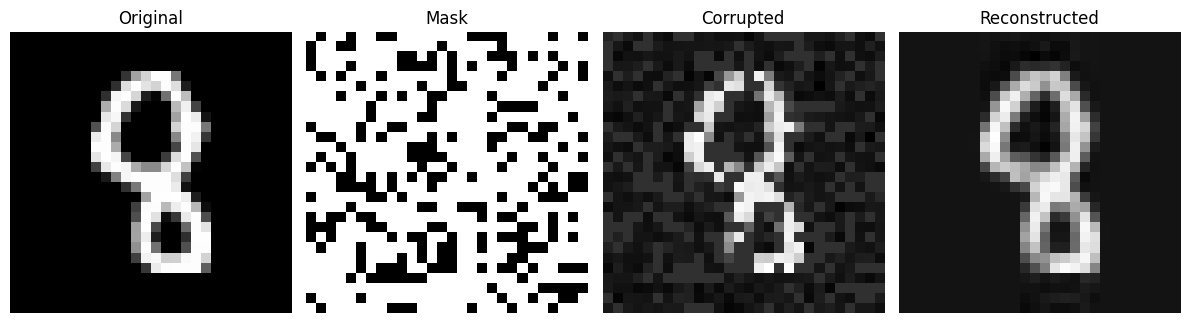

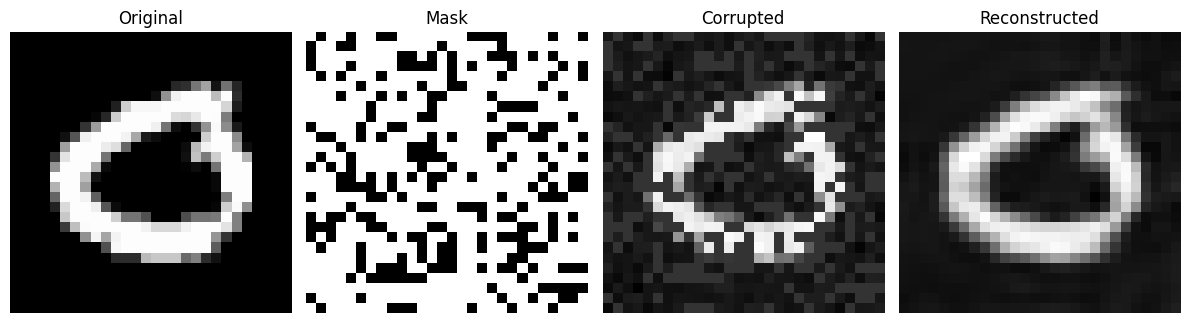

In [3]:
# load data set
num_train = 1024
H, W = 28,28

# load training data chunks
chunk_files_train = sorted([f for f in os.listdir(data_folder_path) if f.startswith("mnist_inpainting_pnp_train")])

all_cor_data_train = []
all_rec_data_train = []
all_clean_data_train = []
all_start_idx_train = []

for file in chunk_files_train:
    if int(file.split('_')[-2]) < num_train:
        chunk = torch.load(os.path.join(data_folder_path, file))
        all_cor_data_train.append(chunk['cor_data'])
        all_rec_data_train.append(chunk['rec_data'])
        all_clean_data_train.append(chunk['clean_data'])
        all_start_idx_train.append(chunk['end_index'] + 1)

# ensure we have enough training data
start_idx_ckpt = max(all_start_idx_train)
assert start_idx_ckpt >= num_train, "not enough training data available!"

# extract mask from one of the chunks
mask = chunk['mask']

# concatenate all training data chunks
cor_data_train_ckpt = torch.cat(all_cor_data_train, dim=0)
rec_data_train_ckpt = torch.cat(all_rec_data_train, dim=0)
clean_data_train_ckpt = torch.cat(all_clean_data_train, dim=0)

# extract training data
cor_data_train = cor_data_train_ckpt[:num_train]
rec_data_train = rec_data_train_ckpt[:num_train]
clean_data_train = clean_data_train_ckpt[:num_train]

# construct train loader from cor_data_train and rec_data_train
batch_size = 64
train_dataset = torch.utils.data.TensorDataset(cor_data_train, rec_data_train)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# Show original, mask, corrupted, and reconstructed images
for i in range(6):
    show_images(
            [clean_data_train[i], mask, cor_data_train[i], rec_data_train[i]],
            ["Original", "Mask", "Corrupted", "Reconstructed"]
        )

### Learning Pullback Geometry ###

In [4]:
# define physics operator
class MaskedForward(nn.Module):
    def __init__(self, mask, pseudo_inverse_reg=None):
        super().__init__()
        self.mask = mask
        self.lambd = pseudo_inverse_reg
    
    def forward(self, x):
        return self.mask.to(x.device) * x
    
    def pseudo_inverse(self, y):
        if self.lambd is not None:
            return 1 / (1 + self.lambd) * self.mask.to(y.device) * y
        else:
            return self.mask.to(y.device) * y

In [5]:
# define the normalizing flow model
def create_flow_model(in_channels, height, width, kernel_size, latent_channels, order, n_flows, unit_det=False, parity_equivariance=False):
    base_dist = distributions.StandardNormal(shape=[in_channels, height, width])
    transforms_list = []
    for i in range(n_flows):
        transforms_list.append(ActNorm(features=in_channels))
        transforms_list.append(ParityConv2DTransform(in_channels, height, width, kernel_size, parity=i, unit_det=unit_det, parity_equivariance=parity_equivariance))
        transforms_list.append(ParityConv2DTransform(in_channels, height, width, kernel_size, parity=i+1, unit_det=unit_det, parity_equivariance=parity_equivariance))
        transforms_list.append(MultiLayerTanhParityConv2DTransform(in_channels, height, width, kernel_size, latent_channels, order=order, parity=i))
    transforms_list.append(ActNorm(features=in_channels))
    transforms_list.append(ParityConv2DTransform(in_channels, height, width, kernel_size, parity=n_flows, unit_det=unit_det, parity_equivariance=parity_equivariance))
    transforms_list.append(ParityConv2DTransform(in_channels, height, width, kernel_size, parity=n_flows+1, unit_det=unit_det, parity_equivariance=parity_equivariance))
    flow_transforms = transforms.CompositeTransform(transforms_list)
    return NFlowImageDiffeomorphism(1, height, width, flows.Flow(transform=flow_transforms, distribution=base_dist))

In [6]:
# define context encoder
class CNN(nn.Module):
    def __init__(self, in_channels: int, hidden_channels: int):
        super().__init__()
        layers = []
        layers.append(nn.Conv2d(in_channels, hidden_channels, kernel_size=3, padding=1))
        layers.append(nn.ReLU())
        layers.append(nn.Conv2d(hidden_channels, hidden_channels, kernel_size=3, padding=1))
        layers.append(nn.ReLU())
        layers.append(nn.Conv2d(hidden_channels, in_channels, kernel_size=3, padding=1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

class DualOutputNet(nn.Module):
    def __init__(self, in_channels: int, hidden_channels: int):
        super().__init__()
        self.cnn = CNN(in_channels, hidden_channels)

    def forward(self, x):
        cnn_out = self.cnn(x)
        out = torch.cat([x, cnn_out], dim=1)  # concatenate along channel dimension
        return out

In [7]:
# define the conditional normalizing flow model
def create_conditional_distribution_model(in_channels, height, width, hidden_channels):
    context_encoder = DualOutputNet(in_channels, hidden_channels)
    return distributions.ConditionalDiagonalNormal(shape=[in_channels, height, width], context_encoder=context_encoder)

In [8]:
# initialize the model
forward = MaskedForward(mask)

L = 64
K = 5
order = 2
n_flows = 3
prior_nflow_diffeo = create_flow_model(1, H, W, K, L, order, n_flows)

M = 16
posterior_dist = create_conditional_distribution_model(1, H, W, M)

noise_level = 0.1
model = PnPRiemannianAmbientFlowProblem(forward, prior_nflow_diffeo, posterior_dist, noise_level).to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [9]:
# Training loop
def train(model, train_loader, optimizer, n_epochs, save_dir, start_epoch=0):
    best_loss = float('inf')
    os.makedirs(save_dir, exist_ok=True)

    for epoch in range(start_epoch, n_epochs):
        model.train()
        epoch_loss = 0
        for y, x_y in tqdm(train_loader, desc=f"Epoch {epoch+1}/{n_epochs}"):
            optimizer.zero_grad()
            
            y = y.to(device)
            x_y = x_y.to(device)
            # Compute loss
            loss = model.reconstruction_loss(y, x_y)

            # Backward pass and optimization
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
        
        # Calculate average loss for the epoch
        avg_epoch_loss = epoch_loss / len(train_loader)
        print(f"Epoch {epoch+1}/{n_epochs}, Average Loss: {avg_epoch_loss:.4f}")
        model.eval()
        with torch.no_grad():
            # Get first 6 samples from next batch
            sample_images, _ = next(iter(train_loader))
            sample_images = sample_images.to(device)
            sample_outputs = model.reconstruct(sample_images)
            
            # Convert to numpy arrays
            outputs_np = sample_outputs[:6].cpu().numpy().squeeze()
            samples_np = sample_images[:6].cpu().numpy().squeeze()

            # Create 2x6 grid
            fig, axes = plt.subplots(2, 6, figsize=(15, 4))
            for i in range(6):
                axes[0,i].imshow(samples_np[i], cmap='gray') 
                axes[0,i].axis('off')
                axes[1,i].imshow(outputs_np[i], cmap='gray')
                axes[1,i].axis('off')
            
            plt.suptitle(f'Epoch {epoch+1} Reconstructions', y=1.02)
            plt.tight_layout()
            plt.show()

        # Save checkpoint
        checkpoint = {
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': loss,
            'best_loss': best_loss,
        }
        
        if (epoch + 1) % 5 == 0:
            torch.save(checkpoint, os.path.join(save_dir, f'epoch_{epoch+1}_model.pth'))

        if avg_epoch_loss < best_loss:
            best_loss = avg_epoch_loss
            torch.save(checkpoint, os.path.join(save_dir, 'best_model.pth'))

    print("Training completed. Best model saved with loss:", best_loss)

In [10]:
# Train the model
n_epochs = 100
checkpoint_dir = os.path.join(results_folder_path, f"checkpoints_latent_dim{L}_kernel_size{K}_order{order}_n_flows{n_flows}")

# Train or load model
train_model = True
if train_model:
    start_epoch = 0
    best_loss = float('inf')

    # Check if there's a checkpoint to resume from
    latest_checkpoint = max(glob.glob(os.path.join(checkpoint_dir, 'epoch_*_model.pth')), default=None, key=os.path.getctime)
    
    if latest_checkpoint:
        print(f"Resuming training from {latest_checkpoint}")
        checkpoint = torch.load(latest_checkpoint)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        start_epoch = checkpoint['epoch'] + 1
        best_loss = checkpoint['best_loss']

    train(model, train_loader, optimizer, n_epochs, checkpoint_dir, start_epoch=start_epoch)
else:
    # best_model_path = os.path.join(checkpoint_dir, 'epoch_200_model.pth')
    best_model_path = os.path.join(checkpoint_dir, 'best_model.pth')
    checkpoint = torch.load(best_model_path)
    model.load_state_dict(checkpoint['model_state_dict'])

# Set the model to evaluation mode
model.eval()

Epoch 1/100:  12%|█▎        | 2/16 [00:27<03:13, 13.81s/it]


KeyboardInterrupt: 

### Evaluating Pullback Geometry ###